<Axes: title={'center': 'Tasa de compra por grupo de salario'}, xlabel='SalaryGroup', ylabel='Tasa de compra (0 a 1)'>

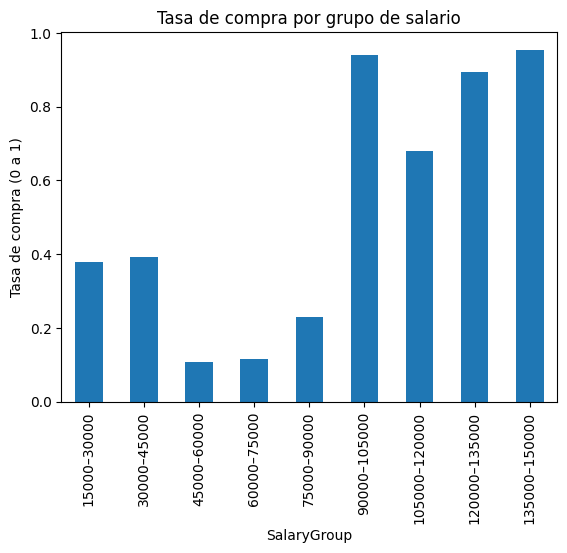

In [57]:
import pandas as pd
import numpy as np
import math

df = pd.read_csv("./Social_Network_Ads.csv")

# -------- Age Group --------
age = df["Age"]
bins = np.linspace(age.min(), age.max(), int(math.sqrt(age.max())))
labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(len(bins) - 1)]
df["AgeGroup"] = pd.cut(age, bins=bins, labels=labels)

# -------- Salary --------
salary = df["EstimatedSalary"]
bins = np.linspace(salary.min(), salary.max(), 10)
labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(len(bins) - 1)]
df["SalaryGroup"] = pd.cut(salary, bins=bins, labels=labels)

purchase_by_agegroup = df.groupby("AgeGroup", observed=True)["Purchased"].mean()
purchase_by_salary = df.groupby("SalaryGroup", observed=True)["Purchased"].mean()

purchase_by_salary.plot(kind='bar', title='Tasa de compra por grupo de salario', ylabel='Tasa de compra (0 a 1)')

In [58]:
X = df.loc[:, ["Age", "EstimatedSalary"]]
y = df["Purchased"]

y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 400 entries, 0 to 399
Series name: Purchased
Non-Null Count  Dtype
--------------  -----
400 non-null    int64
dtypes: int64(1)
memory usage: 3.3 KB


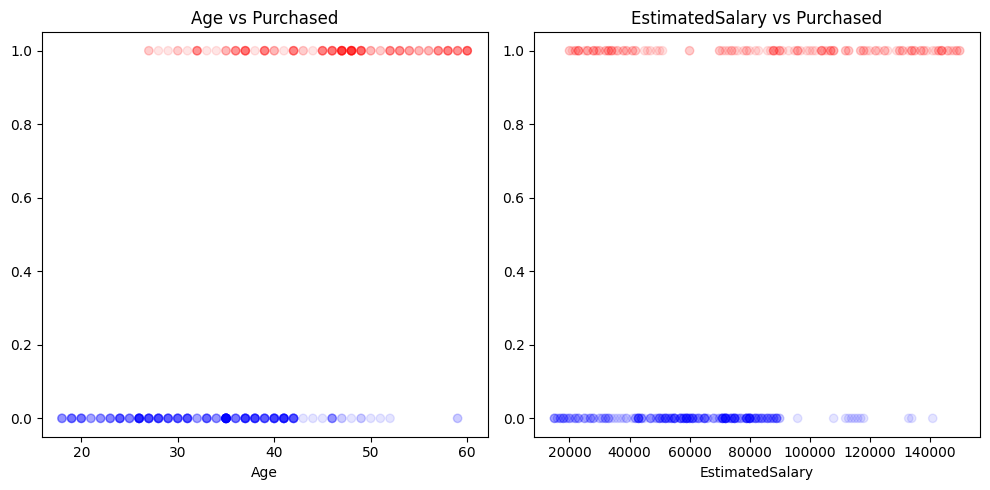

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, X.columns.size, figsize=(5 * X.columns.size, 5))

for i, column in enumerate(X.columns):
    axes[i].scatter(df[column], y, c=df["Purchased"], cmap="bwr", alpha=0.1)
    axes[i].set_xlabel(column)
    axes[i].set_title(f"{column} vs Purchased")

plt.tight_layout()
plt.show()

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0, test_size=0.25
)

pipeline = Pipeline([
  ("scaler", StandardScaler()),
  ("model", LogisticRegression(random_state=0))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Precisión:", accuracy_score(y_test, y_pred))

Precisión: 0.89


[[65  3]
 [ 8 24]]


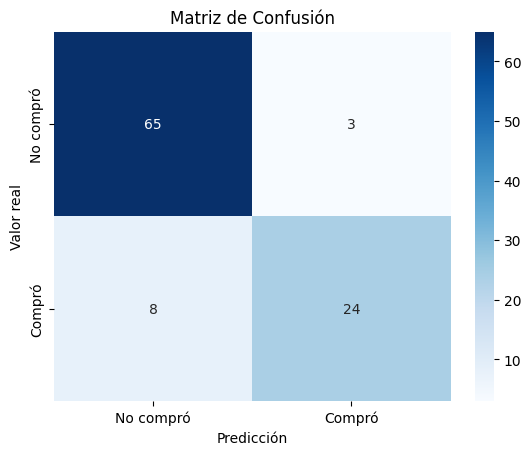

In [61]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No compró", "Compró"], yticklabels=["No compró", "Compró"])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
True, fmt="d", cmap="Blues", xticklabels=["No compró", "Compró"], yticklabels=["No compró", "Compró"])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()